In [1]:
# gemelli env
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skbio import DistanceMatrix
from skbio.stats.distance import permanova
from biom import load_table
from biom.table import Table
import seaborn as sns

from gemelli.rpca import rpca
from scipy.spatial import procrustes
from skbio.stats.distance import mantel

from adjustText import adjust_text

In [45]:
table = load_table('out/rarefied_table.biom')
metadata = pd.read_csv('qiita_artifacts/25761_25761_analysis_mapping.txt', sep='\t')
metadata = metadata.set_index('SampleID')

In [46]:
def run_rpca(table, metadata, target_column):
    ordination, distance = rpca(table)
    samples_df = ordination.samples
    
    target_data = {}

    for sample_id in samples_df.index:
        val = metadata.loc[sample_id, target_column]
        target_data[sample_id] = val

    df = samples_df.copy()

    # Add cohort information to the samples dataframe
    df[target_column] = pd.Series(target_data)

    # Extract variance explained
    variance_explained = ordination.proportion_explained
    
    return ordination, distance, df, variance_explained

In [47]:
df = table.to_dataframe()
df.shape, metadata.shape

((3326, 611), (683, 58))

In [48]:
metadata.columns

Index(['BarcodeSequence', 'LinkerPrimerSequence', 'center_name',
       'experiment_design_description', 'instrument_model',
       'library_construction_protocol', 'linker', 'pcr_primers', 'platform',
       'run_center', 'run_prefix', 'sequencing_meth', 'target_gene',
       'target_subfragment', 'qiita_prep_id', 'bmi', 'body_habitat',
       'body_product', 'body_site', 'calprotectin', 'cd_behavior',
       'cd_location', 'cd_resection', 'collection_timestamp', 'diagnosis_full',
       'dna_extracted', 'env_biome', 'env_feature', 'env_material',
       'env_package', 'fecal_date', 'geo_loc_name', 'host_common_name',
       'host_scientific_name', 'host_subject_id', 'host_taxid', 'ibd_subtype',
       'latitude', 'longitude', 'patientnumber', 'perianal_disease',
       'physical_specimen_location', 'physical_specimen_remaining',
       'qiita_study_id', 'sample_type', 'scientific_name', 'sex', 'study',
       'study_id', 'timepoint', 'uc_extent', 'year_diagnosed',
       'qiita_artif

In [49]:
metadata['cd_behavior'].value_counts()

cd_behavior
not applicable                           432
Non-stricturing, non-penetrating (B1)    115
Stricturing (B2)                         103
Penetrating (B3)                          33
Name: count, dtype: int64

In [50]:
metadata['cd_phenotype'] = metadata['cd_behavior'].map({
    'Non-stricturing, non-penetrating (B1)': 'B1', 
    'not applicable': np.nan,
    'Stricturing (B2)': 'B-other',
    'Penetrating (B3)': 'B-other'
})

In [51]:
metadata['cd_phenotype'].value_counts()

cd_phenotype
B-other    136
B1         115
Name: count, dtype: int64

In [52]:
target_column = 'cd_phenotype'

ordination, distance, df, variance_explained = run_rpca(table, metadata, target_column)

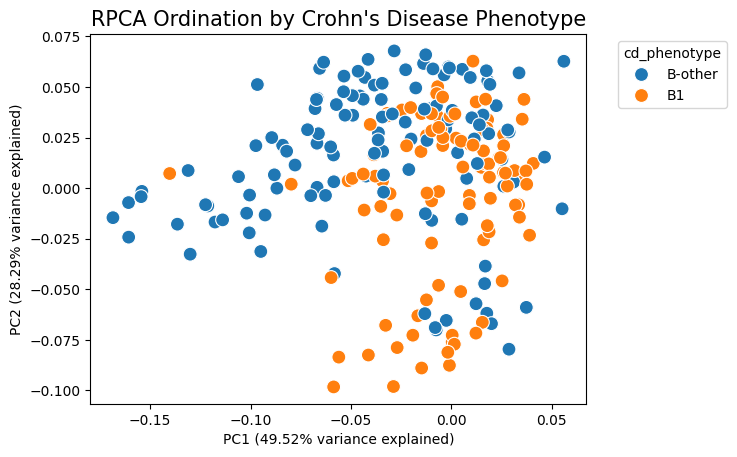

In [55]:
# Create the RPCA plot with PERMANOVA results annotation
sns.scatterplot(
    data=df,
    x='PC1', 
    y='PC2',
    hue=target_column,
    s=100,
)

plt.title('RPCA Ordination by Crohn\'s Disease Phenotype', fontsize=15)

plt.xlabel(f'PC1 ({variance_explained[0]:.2%} variance explained)')
plt.ylabel(f'PC2 ({variance_explained[1]:.2%} variance explained)')

# Adjust legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='cd_phenotype')

# Save plot
plt.savefig('figs/rpca_ordination.png', dpi=300, bbox_inches='tight')
plt.show()